In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import RocCurveDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score, StratifiedKFold

**OPENING THE CSV**

In [2]:
df = pd.read_csv('ai4i2020.csv')
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


**UNDERSTANDING DATA**

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

In [4]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [5]:
df.shape

(10000, 14)

In [6]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [7]:
df.nunique()

UDI                        10000
Product ID                 10000
Type                           3
Air temperature [K]           93
Process temperature [K]       82
Rotational speed [rpm]       941
Torque [Nm]                  577
Tool wear [min]              246
Machine failure                2
TWF                            2
HDF                            2
PWF                            2
OSF                            2
RNF                            2
dtype: int64

In [8]:
for col in ['Type', 'Machine failure']:
    print(f"Unique values in {col}:", df[col].unique())

Unique values in Type: <StringArray>
['M', 'L', 'H']
Length: 3, dtype: str
Unique values in Machine failure: [0 1]


In [9]:
df['Machine failure'].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

**Total samples = 10,000 ,**
**Failure cases = 339 ,**
**Non-failure cases = 9,661.**

**This means the dataset is imbalanced**

Text(0.5, 1.0, 'Machine Failure Distribution')

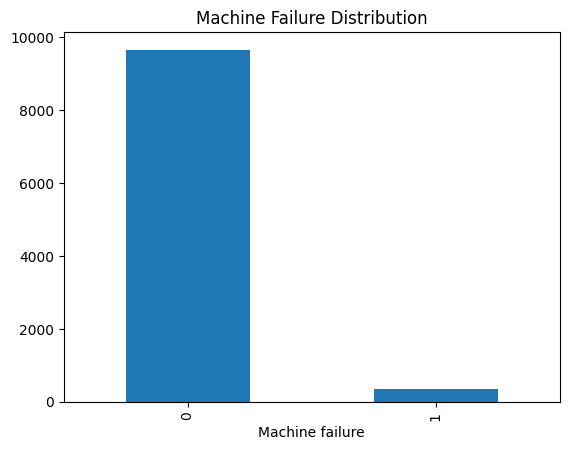

In [10]:
#Failure Distribution

df['Machine failure'].value_counts().plot(kind='bar')
plt.title("Machine Failure Distribution")

Text(0.5, 1.0, 'Product type machine failure count')

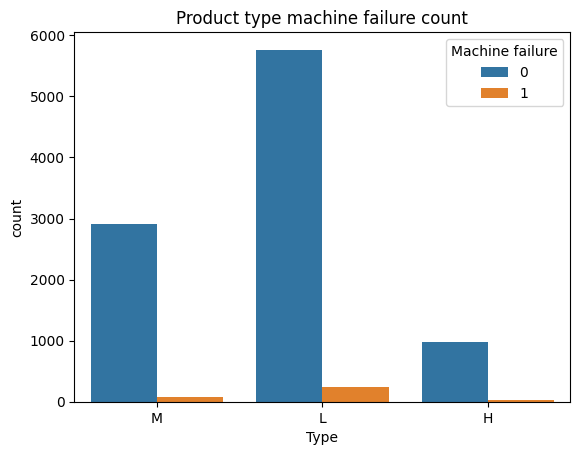

In [11]:
#Failure by Product Type

ax=sns.countplot(
    x='Type',
    hue='Machine failure',
    data=df
)
ax.set_title('Product type machine failure count')

<Axes: >

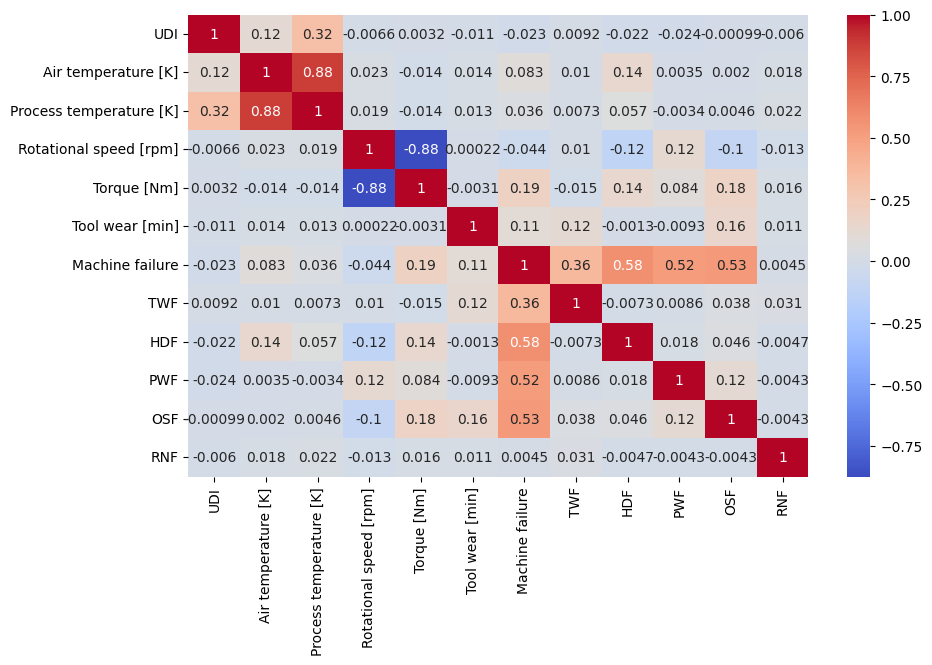

In [12]:
# corelation heatmap

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

**SUMMARY OF HEATMAP**

1.  Relation of Air temperature and Process temperature is highest 0.88. 

It tells us that as the ambient air temperature increases, the internal process temperature of the machine rises almost perfectly in tandem. They are highly redundant features.

2. The inverse relation of Rotational speed and torque(-0.88) : When the machine spins faster (higher RPM), the torque drops significantly, and vice versa.


3. While Machine Failure is mostly affected by : HDF (Heat Dissipation Failure): 0.58

correlationOSF (Overstrain Failure): 0.53 

correlationPWF (Power Failure): 0.52 

correlationTWF (Tool Wear Failure): 0.36 correlation



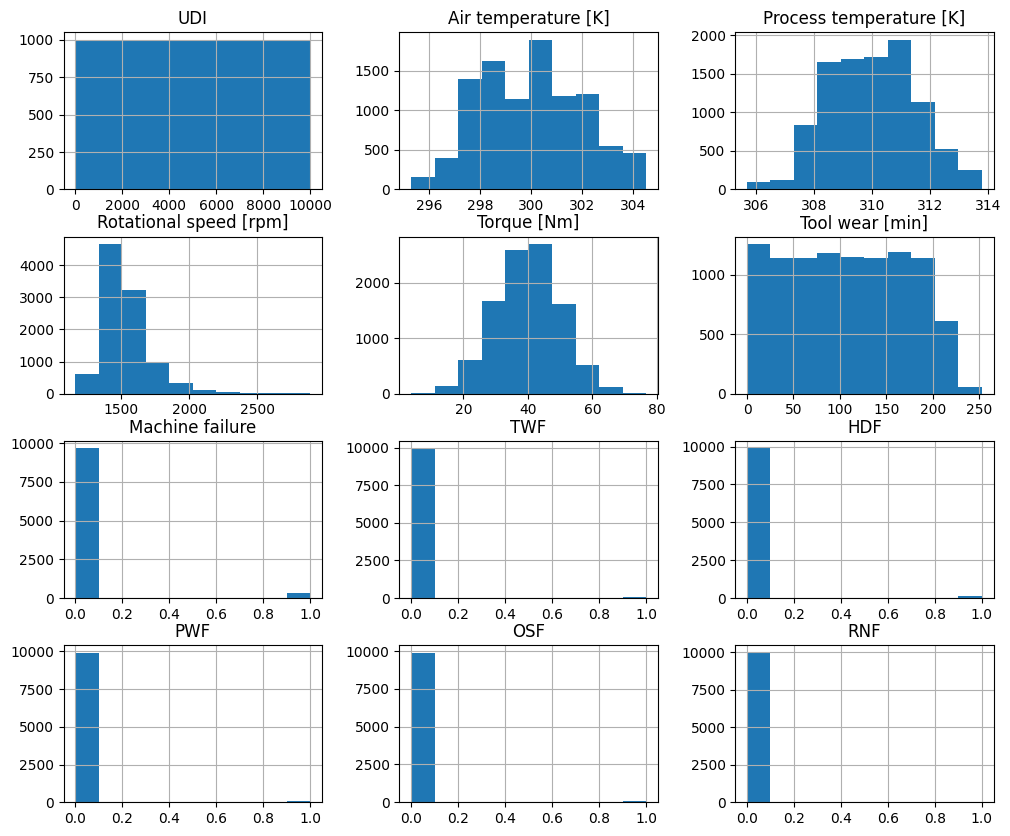

In [13]:
#histogram (distribution of each feature)

df.hist(figsize=(12,10))
plt.show()

In [14]:
print(df.columns)

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='str')


In [15]:
#encode product type

le = LabelEncoder()
df['Type'] = le.fit_transform(df['Type'])

print("Encoded classes:", le.classes_)

mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(mapping)

Encoded classes: ['H' 'L' 'M']
{'H': np.int64(0), 'L': np.int64(1), 'M': np.int64(2)}


In [16]:
#Define Features and Target

le = LabelEncoder()
df['Type'] = le.fit_transform(df['Type'])

X = df.drop('Machine failure', axis=1)
y = df['Machine failure']

print(X.dtypes)

UDI                          int64
Product ID                     str
Type                         int64
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object


In [17]:

#  Define Features and Target (Drop the text identifier columns)
X = df.drop(['Machine failure', 'UDI', 'Product ID'], axis=1)
y = df['Machine failure']

#  Test-Train Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#  Feature Scaling (This will now run perfectly!)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## MULTIPLE MODEL TRAINING 

In [18]:
# logistic regression

lr = LogisticRegression()
lr.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

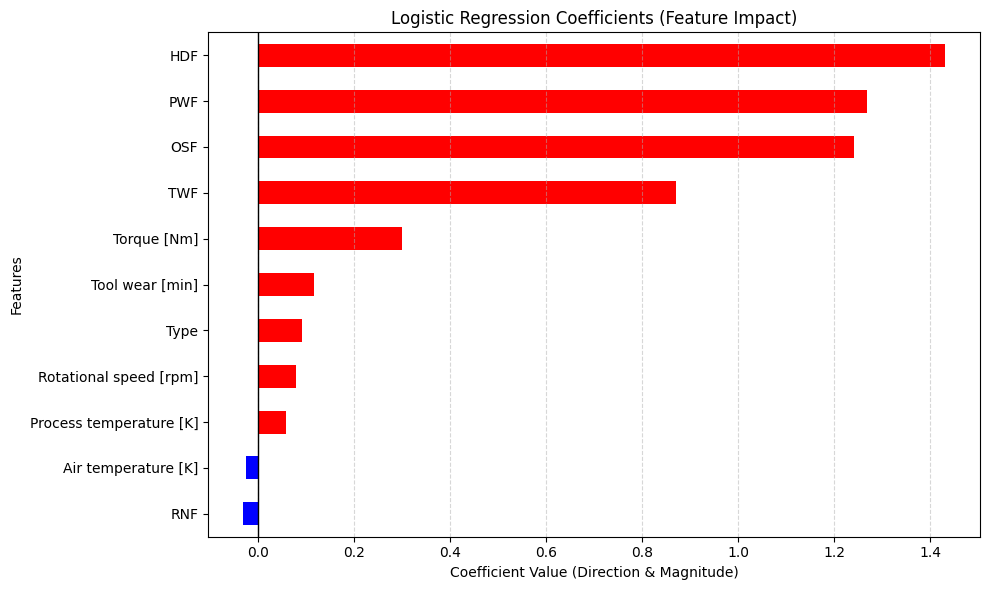

In [19]:
#  Get the coefficients from the logistic regression model
coefficients = lr.coef_[0]
feature_names = X.columns

#  Create a pandas Series for easy sorting and plotting
lr_importance = pd.Series(coefficients, index=feature_names)

#  Plot the coefficients
plt.figure(figsize=(10, 6))
# Using a color map or conditional coloring to distinguish positive/negative relationships
colors = ['red' if c > 0 else 'blue' for c in lr_importance.sort_values()]
lr_importance.sort_values().plot(kind='barh', color=colors)

plt.title("Logistic Regression Coefficients (Feature Impact)")
plt.xlabel("Coefficient Value (Direction & Magnitude)")
plt.ylabel("Features")
def_grid = plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.axvline(x=0, color='black', linestyle='-', linewidth=1) # Reference line at 0
plt.tight_layout()
plt.show()

In [20]:
# random forest

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

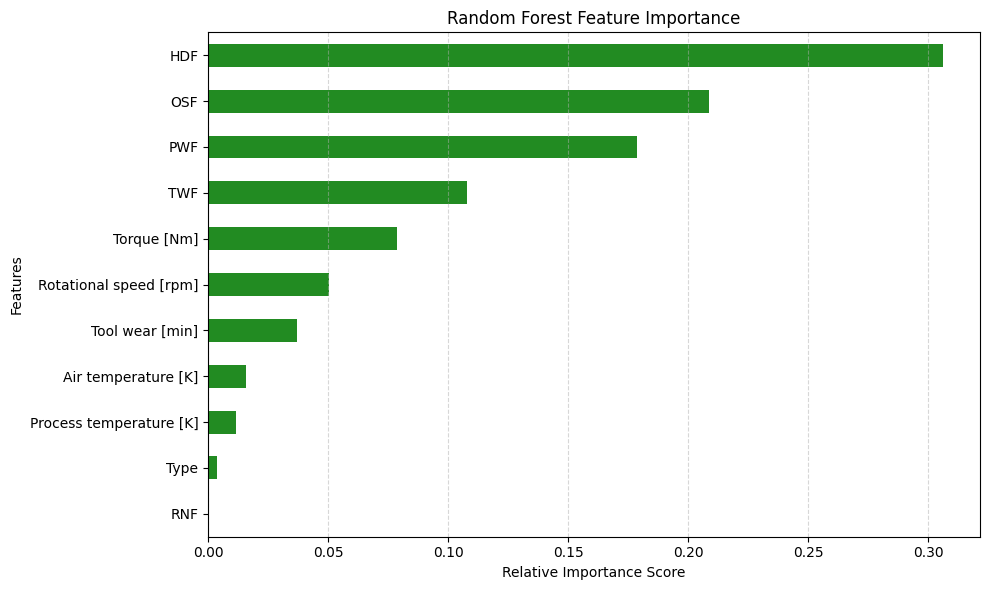

In [21]:
#  Get feature importances from the random forest model
importances = rf.feature_importances_
feature_names = X.columns

#  Create a pandas Series and sort it
rf_importance = pd.Series(importances, index=feature_names).sort_values(ascending=True)

#  Plot the feature importances
plt.figure(figsize=(10, 6))
rf_importance.plot(kind='barh', color='forestgreen')

plt.title("Random Forest Feature Importance")
plt.xlabel("Relative Importance Score")
plt.ylabel("Features")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

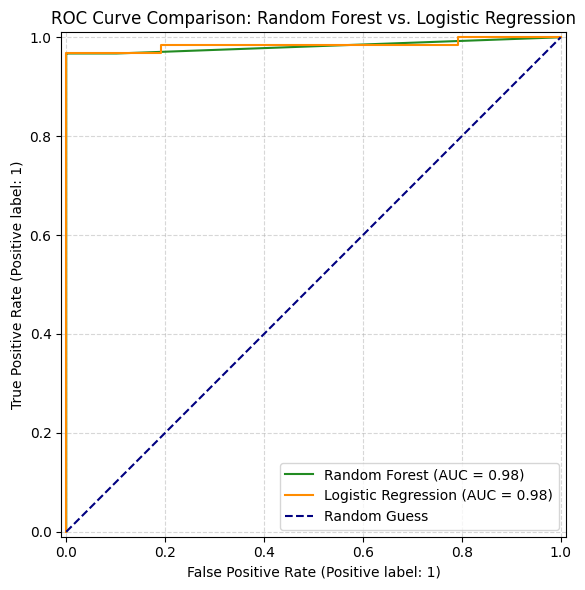

In [22]:
#  Create a single plot frame
fig, ax = plt.subplots(figsize=(8, 6))

#  Plot ROC for Random Forest and set its color manually
rf_disp = RocCurveDisplay.from_estimator(rf, X_test, y_test, ax=ax, name='Random Forest')
rf_disp.line_.set_color('forestgreen')

#  Plot ROC for Logistic Regression and set its color manually
lr_disp = RocCurveDisplay.from_estimator(lr, X_test, y_test, ax=ax, name='Logistic Regression')
lr_disp.line_.set_color('darkorange')


plt.plot([0, 1], [0, 1], color='navy', linestyle='--', label='Random Guess')
plt.title("ROC Curve Comparison: Random Forest vs. Logistic Regression")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()

In [23]:
# decision tree

dt = DecisionTreeClassifier()

dt.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

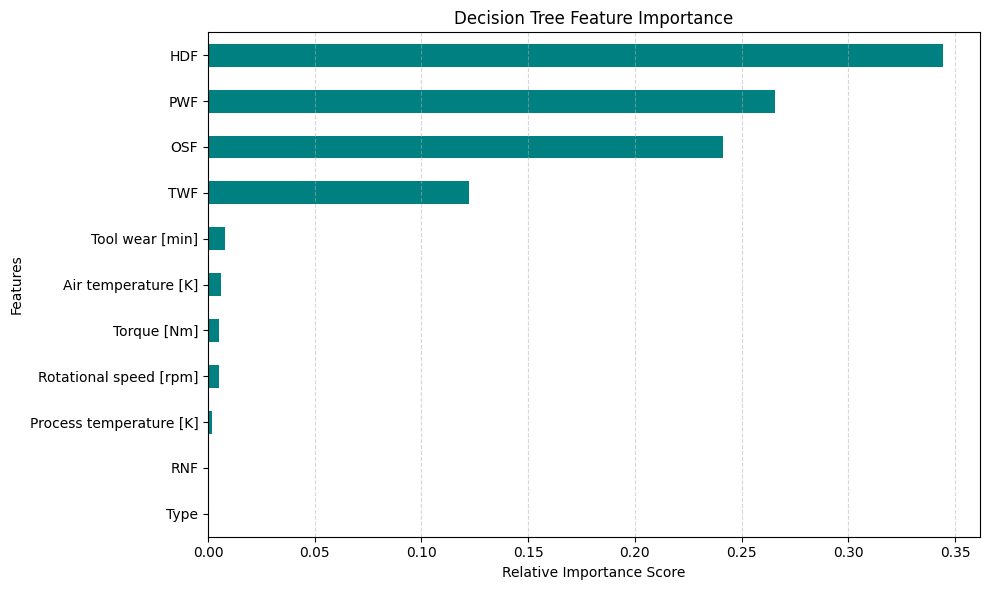

In [24]:
# Create a pandas Series for Decision Tree importances
dt_importance = pd.Series(dt.feature_importances_, index=X.columns).sort_values(ascending=True)

# Plot the feature importances
plt.figure(figsize=(10, 6))
dt_importance.plot(kind='barh', color='teal')

plt.title("Decision Tree Feature Importance")
plt.xlabel("Relative Importance Score")
plt.ylabel("Features")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [25]:
#comprehensive model comparison

models = {
    'Logistic Regression': lr,
    'Random Forest': rf,
    'Decision Tree': dt
}

summary_data = []
for name, model in models.items():
    preds = model.predict(X_test)
    summary_data.append({
        'Model': name,
        'Precision (Failures)': precision_score(y_test, preds),
        'Recall (Failures)': recall_score(y_test, preds),
        'F1-Score (Failures)': f1_score(y_test, preds)
    })

df_summary = pd.DataFrame(summary_data)
print(df_summary)

                 Model  Precision (Failures)  Recall (Failures)  \
0  Logistic Regression              1.000000           0.967213   
1        Random Forest              1.000000           0.967213   
2        Decision Tree              0.951613           0.967213   

   F1-Score (Failures)  
0             0.983333  
1             0.983333  
2             0.959350  


**SUMMARY OF COMPREHENSIVE MODEL COMPARISON**
Logistic Regression and Random Forest models easily achieved near-perfection by mapping failure modes (i.e TWF, HDF, PWF, OSF) directly to the target.

While the current baseline models achieve an exceptional **F1-score of 0.98** due to the inclusion of failure diagnostic flags, the next phase of this project will drop the operational failure modes (TWF, HDF, etc.) and retrain the models strictly on raw sensor telemetry (Torque, Rotational Speed, and Temperature Differentials). This will test how well the **Random Forest** can forecast failures before a diagnostic flag is triggered.

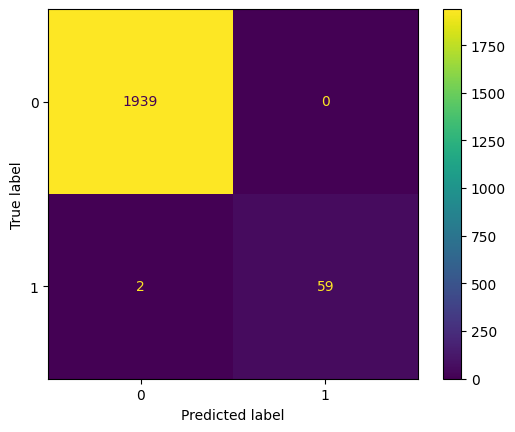

In [26]:
#confusion matrix 

ConfusionMatrixDisplay.from_estimator(
    rf,
    X_test,
    y_test
)

plt.show()

1. False Positives are at exactly 0, your maintenance team would never waste time or money pulling a perfectly healthy machine offline for an unnecessary inspection. This gives you a **Precision score of** $100\%$.

2. Out of 61 total failure cases in your test set, your model successfully caught 59 of them. This gives you a **Recall score of** $96.72\%$.

## EVALUATION WITHOUT DIAGNOSTIC FLAGS

## OR

## REAL-WORLD PERFORMANCE EVALUATION

In [27]:
df = df.drop(['TWF', 'HDF', 'PWF', 'OSF', 'RNF'], axis=1)
df

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,1,M14860,2,298.1,308.6,1551,42.8,0,0
1,2,L47181,1,298.2,308.7,1408,46.3,3,0
2,3,L47182,1,298.1,308.5,1498,49.4,5,0
3,4,L47183,1,298.2,308.6,1433,39.5,7,0
4,5,L47184,1,298.2,308.7,1408,40.0,9,0
...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,2,298.8,308.4,1604,29.5,14,0
9996,9997,H39410,0,298.9,308.4,1632,31.8,17,0
9997,9998,M24857,2,299.0,308.6,1645,33.4,22,0
9998,9999,H39412,0,299.0,308.7,1408,48.5,25,0


### Why Diagnostic Flags Were Removed?
During the baseline evaluation, columns like `TWF` (Tool Wear Failure), `HDF` (Heat Dissipation Failure), `PWF` (Power Failure), and `OSF` (Overstrain Failure) were included as training features. Because these flags are generated simultaneously with or after a failure occurs, the baseline models effectively "cheated" by reading the exact reasons for a crash to predict that a crash happened, resulting in an artificially perfect but unrealistic F1-Score of 0.98.

To transform this into a true **Predictive Maintenance** system, these diagnostic flags were dropped. The models are now forced to forecast failures strictly using raw, real-time sensor telemetry—such as torque, rotational speed, and temperature differentials—simulating how the model would actually behave on a real factory floor before any breakdown occurs.

In [28]:
X = df.drop(['Machine failure', 'UDI', 'Product ID'], axis=1)
y = df['Machine failure']

#  Test-Train Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#  Feature Scaling (This will now run perfectly!)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# logistic regression

lr = LogisticRegression()
lr.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

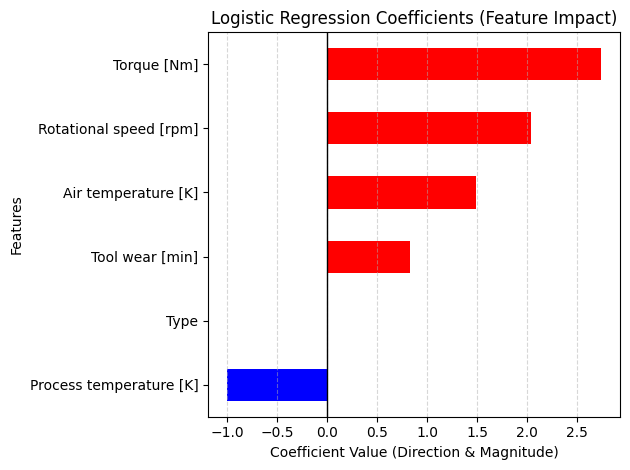

In [29]:
#  Get the coefficients from the logistic regression model
coefficients = lr.coef_[0]
feature_names = X.columns

#  Create a pandas Series for easy sorting and plotting
lr_importance = pd.Series(coefficients, index=feature_names)

#  Plot the coefficients
# Using a color map or conditional coloring to distinguish positive/negative relationships
colors = ['red' if c > 0 else 'blue' for c in lr_importance.sort_values()]
lr_importance.sort_values().plot(kind='barh', color=colors)

plt.title("Logistic Regression Coefficients (Feature Impact)")
plt.xlabel("Coefficient Value (Direction & Magnitude)")
plt.ylabel("Features")
def_grid = plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.axvline(x=0, color='black', linestyle='-', linewidth=1) # Reference line at 0
plt.tight_layout()
plt.show()

In [30]:
# random forest

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

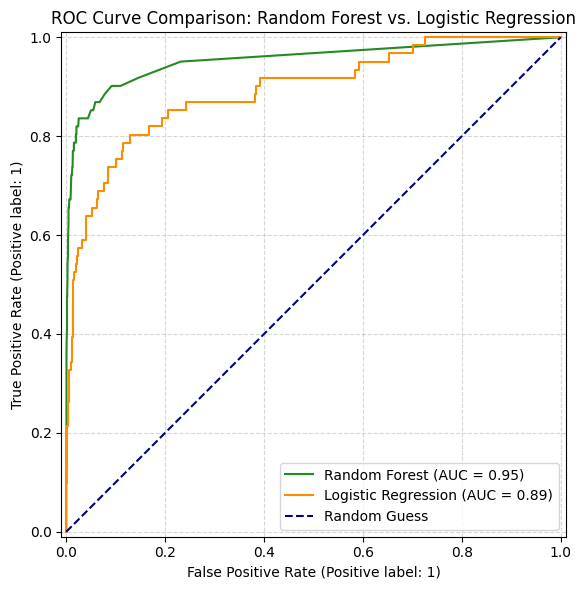

In [31]:
#  Create a single plot frame
fig, ax = plt.subplots(figsize=(8, 6))

#  Plot ROC for Random Forest and set its color manually
rf_disp = RocCurveDisplay.from_estimator(rf, X_test, y_test, ax=ax, name='Random Forest')
rf_disp.line_.set_color('forestgreen')

#  Plot ROC for Logistic Regression and set its color manually
lr_disp = RocCurveDisplay.from_estimator(lr, X_test, y_test, ax=ax, name='Logistic Regression')
lr_disp.line_.set_color('darkorange')


plt.plot([0, 1], [0, 1], color='navy', linestyle='--', label='Random Guess')
plt.title("ROC Curve Comparison: Random Forest vs. Logistic Regression")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()

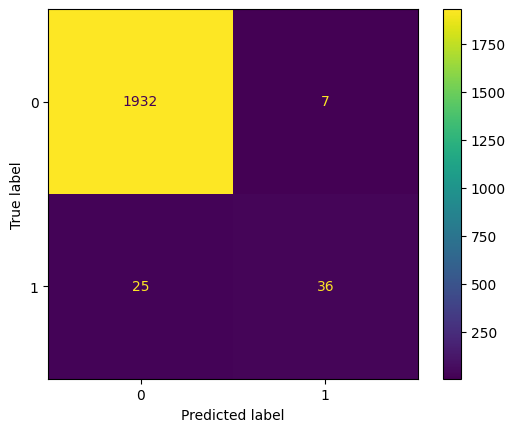

In [32]:
#confusion matrix 

ConfusionMatrixDisplay.from_estimator(
    rf,
    X_test,
    y_test
)

plt.show()

In [33]:
#cross-validation

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in [('Logistic Regression', lr), ('Random Forest', rf)]:
    scores = cross_val_score(model, X, y, cv=cv, scoring='f1')
    print(f"{name}: F1 = {scores.mean():.3f} (+/- {scores.std():.3f})")

C:\Users\dell\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression: F1 = 0.306 (+/- 0.051)
Random Forest: F1 = 0.694 (+/- 0.046)


In [34]:
models = {'Logistic Regression': lr, 'Random Forest': rf}
summary_data = []

for name, model in models.items():
    preds = model.predict(X_test)
    summary_data.append({
        'Model': name,
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1-Score': f1_score(y_test, preds)
    })

df_summary = pd.DataFrame(summary_data)
print(df_summary)

                 Model  Precision    Recall  F1-Score
0  Logistic Regression   0.640000  0.262295  0.372093
1        Random Forest   0.837209  0.590164  0.692308


<div style = "
    background-color: #FFD580;
    padding: 15px;
    text-align: centre;
    font-weight: bold;
    color: black;
    font-size: 30px;
    border-radius: 8px;">
    CONCLUSION 
</div>


1. **The Reality Check:** Once the diagnostic failure flags (`TWF`, `HDF`, etc.) were removed, the artificially perfect F1-Score of 0.98 dropped to a realistic performance baseline. This drop proves that the initial iteration was simply memorizing post-failure symptoms rather than predicting them.

2. **Random Forest is the Clear Winner:** Forced to rely entirely on raw sensor data, the **Random Forest Classifier** proved to be robust, achieving a solid **F1-Score of 0.69**. More importantly, it maintained a high **Precision of 83.7%**, meaning that when the model sounds an alarm, there is a very high probability that a machine is genuinely deteriorating.

3. **Logistic Regression Struggles with Telemetry:** **Logistic Regression** fell sharply to an **F1-Score of 0.37**, hampered by a very low **Recall of 26.2%**. This indicates that the relationships between raw operational sensors (like the non-linear interplay between torque and rotational speed) are too complex for a simple linear model to capture effectively.

4. **Operational Next Steps:** For a reliable deployment on the factory floor, the **Random Forest** model should be selected. While its Recall (59%) means it will miss some failures, its high Precision ensures the maintenance crew won't lose faith in the system due to costly "false alarms."

<div style = "
    background-color: #FFD580;
    padding: 15px;
    text-align: centre;
    font-weight: bold;
    color: black;
    font-size: 30px;
    border-radius: 8px;">
    FUTURE TAKE-AWAY 
</div>


Our transition from a "perfect" baseline ($F1 = 0.98$) to a realistic sensor-only model ($F1 = 0.69$) highlighted that predicting failures using raw telemetry is highly complex but viable. To bridge this performance gap and deploy a production-grade predictive maintenance system, the next phases of the project should focus on three core pillars:

#### 1. Advanced Feature Engineering (Squeezing Value from Sensors)
Because we dropped the diagnostic flags, the models must work harder to extract patterns from raw data. We should explicitly engineer degradation metrics:
*   **Thermal Stress Delta ($\Delta T$):** Create an explicit feature for the difference between process and air temperature ($\Delta T = T_{\text{process}} - T_{\text{air}}$) to directly measure heat dissipation efficiency.
*   **Power & Volatility Proxies:** Calculate a pseudo-power metric ($\text{Torque} \times \text{Rotational Speed}$) and introduce rolling standard deviations over a time window to capture micro-vibrations and stability shifts before a breakdown.

#### 2. Tackling Severe Class Imbalance
With failure events making up only 3.39% of our dataset, our winning Random Forest model is still biased toward the majority class, resulting in a suboptimal **Recall of 59%**.
*   **Resampling Techniques:** Implement **SMOTE** (Synthetic Minority Over-sampling Technique) or a combined SMOTE-ENN strategy exclusively on the training split to artificially enrich failure patterns.
*   **Cost-Sensitive Learning:** Leverage algorithmic adjustments like `class_weight='balanced'` or shift to gradient boosting frameworks like **XGBoost** (tuning `scale_pos_weight`), penalizing the model aggressively for missed failures.

#### 3. Shifting from Static Classification to Time-Series Forecasting
In a real factory environment, machines don't fail out of nowhere; they degrade sequentially over time. Treating each row as an isolated moment limits our predictive capability.
*   **Sequential Modeling:** Restructure the dataset into time windows (e.g., look-back periods of the last 10–15 minutes) and implement **LSTM (Long Short-Term Memory)** networks or GRUs.
*   **Remaining Useful Life (RUL):** Pivot the core machine learning problem from binary classification (*Will it fail right now?*) to a regression paradigm (*How many operational minutes are left before failure?*), giving maintenance crews a clearer window to schedule repairs.